# TP — Optimiser la Random Forest et tracer chaque essai avec MLflow

**Objectif :** obtenir une comparaison reproductible avant/après, comprendre chaque résultat et défendre le choix à l'oral. On prédit, pour une machine à une heure donnée, la présence d'une panne dans les **24 prochaines heures** : c'est une classification binaire (cible 0 = non, 1 = oui). Une ligne positive est une **machine-heure**, pas nécessairement une panne distincte.

**Point de départ :** le CSV Gold (table préparée pour l'apprentissage) existe dans `datas/`. La Random Forest du notebook 04 était retenue sur la validation. Une forêt aléatoire agrège les prédictions d'arbres de décision. Le notebook 05 explore déjà une petite grille ; le présent notebook constitue un exercice autonome avec une recherche aléatoire et une traçabilité complète.

## 0. Préparer l'environnement et ouvrir les outils

Dans **PowerShell**, depuis la racine du dépôt :
```powershell
Set-Location C:\source\indusense
uv sync --dev
.\scripts\start-mlflow.ps1
```
`uv sync --dev` installe les versions verrouillées et les outils Jupyter dans `.venv`, environnement Python isolé. Succès : aucune erreur et un bilan des paquets. Le script suivant démarre l'interface MLflow, outil qui conserve les expériences. Le terminal reste occupé : ouvrir **http://127.0.0.1:5000** dans le navigateur. `127.0.0.1` limite l'accès à cette machine ; `5000` est le port.

Dans VS Code, ouvrir ce notebook, cliquer **Select Kernel / Sélectionner le noyau**, puis choisir `C:\source\indusense\.venv\Scripts\python.exe`. Le **noyau** est le processus Python exécutant les cellules. Cliquer **Run All / Tout exécuter**. Une cellule terminée affiche un numéro d'exécution et ses résultats ; une erreur rouge signifie qu'il faut s'arrêter et lire le message. Ne pas exécuter les cellules dans le désordre.

Si `uv` est introuvable ici, utiliser `& "$env:USERPROFILE\.local\bin\uv.exe" sync --dev --python .\.venv\Scripts\python.exe` avec l'environnement installé. Si le port 5000 est occupé, utiliser `./scripts/start-mlflow.ps1 -Port 5001`, puis ouvrir le port 5001. Le notebook écrit directement dans la même base locale et peut fonctionner lorsque l'interface est arrêtée.

## 1. Relier le TP au cours

Source : [09_Optimisation.pdf](../../../docs/02-sprint-2/01-cours/09_Optimisation.pdf), pages 4 à 10 ; [transcription](../../../docs/02-sprint-2/02-transcriptions/06-tuning-des-hyperparametres.txt), notamment 02:30–02:48 (justification orale), 52:18–52:30 (MLflow), 54:10–55:29 (plages plausibles).

| Attente du cours | Application dans ce notebook |
|---|---|
| Distinguer paramètres et hyperparamètres (p. 4) | Les règles des arbres sont apprises ; profondeur et nombre d'arbres sont choisis avant `fit`, l'entraînement. |
| Moyenne et variabilité en cross-validation (p. 5) | Trois **folds**, c'est-à-dire trois couples entraînement/validation, respectent le temps. |
| Comparer les stratégies (p. 6–7) | Random Search retenue ; différences avec Grid Search et Optuna expliquées ci-dessous. |
| Budget, métrique, plages, reproductibilité (p. 8) | 16 configurations, AP, espace borné, graine 42 et journal MLflow. |
| Arbitrer performance et coût (p. 9–10) | Durées réelles et coût des réentraînements ; aucune estimation inventée d'énergie ou de CO₂. |

**Précision au support p. 5 :** l'écart-type des folds mesure leur dispersion ; ce n'est pas un intervalle de confiance. Les folds temporels sont dépendants. Les valeurs illustratives du cours ne sont pas les résultats Indusense. CodeCarbon (énergie) et SHAP (contribution des variables aux prédictions) concernent les prolongements du cours ; ils ne sont pas nécessaires à cette consigne d'optimisation.

**Limite connue dès le départ :** le test historique a déjà été consulté dans les notebooks précédents. Il reste exclu de toute recherche ici, mais ne redevient pas vierge. Une période future inédite sera nécessaire avant une décision de déploiement.

In [1]:
from pathlib import Path
import os
import sys
import json
import hashlib
import logging
import warnings
from time import perf_counter
from importlib.metadata import version

os.environ['MLFLOW_DISABLE_AGENT_HINT'] = '1'
# MLflow répète ces messages à chaque modèle. Les erreurs et autres avertissements restent visibles.
for logger_name in ('mlflow', 'mlflow.sklearn', 'mlflow.utils.environment', 'mlflow.utils.uv_utils'):
    logging.getLogger(logger_name).setLevel(logging.ERROR)
warnings.filterwarnings(
    'ignore',
    message=r'Hint: Inferred schema contains integer column.*',
    category=UserWarning,
    module=r'mlflow\.types\.utils',
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterSampler, ParameterGrid
from sklearn.metrics import (average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, precision_score, recall_score, fbeta_score)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
STORE = ROOT / '.mlflow'
STORE.mkdir(exist_ok=True)
ARTIFACTS = STORE / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)
mlflow.set_tracking_uri('sqlite:///' + (STORE / 'mlflow.db').as_posix())
EXPERIMENT = 'indusense-random-search-pedagogique'
if mlflow.get_experiment_by_name(EXPERIMENT) is None:
    mlflow.create_experiment(EXPERIMENT, artifact_location=ARTIFACTS.as_uri())
experiment = mlflow.set_experiment(EXPERIMENT)
# Journalisation explicite automatisée dans la boucle : aucun doublon d'autolog.
mlflow.sklearn.autolog(disable=True)
versions = {p: version(p) for p in ['mlflow', 'scikit-learn', 'pandas', 'numpy']}
print('Python utilisé :', sys.executable)
for package, v in versions.items():
    print(f'{package} {v} : version logicielle, pas une mesure de performance.')
print('Base persistante :', STORE / 'mlflow.db')
print('Expérience :', EXPERIMENT)
print('MLFLOW_PRET : les essais seront conservés localement, même après fermeture du noyau.')

Python utilisé : C:\source\indusense\.venv\Scripts\python.exe
mlflow 3.16.0 : version logicielle, pas une mesure de performance.
scikit-learn 1.9.1 : version logicielle, pas une mesure de performance.
pandas 3.0.5 : version logicielle, pas une mesure de performance.
numpy 2.5.2 : version logicielle, pas une mesure de performance.
Base persistante : C:\source\indusense\.mlflow\mlflow.db
Expérience : indusense-random-search-pedagogique
MLFLOW_PRET : les essais seront conservés localement, même après fermeture du noyau.


## 2. Charger et auditer les données

Une **feature** est une variable explicative disponible au moment de la prédiction. Les labels et comptages futurs sont exclus pour éviter une **fuite de données**, utilisation d'informations indisponibles en situation réelle. Les identifiants, dates brutes et noms des jeux ne sont pas des entrées du modèle.

Le jeu **train** sert à apprendre et contient les folds de recherche. La **validation dédiée** sert uniquement au seuil d'alerte. Le **test** sert à la comparaison finale. On conserve les jeux fournis et retire, si nécessaire, les 24 dernières heures de train avant la validation et de validation avant le test : les cibles de ces lignes regarderaient sinon dans la période suivante. Cette zone d'exclusion est appelée **gap** ou purge. Si elle change les effectifs, la référence manuelle sera recalculée sur exactement le même protocole que le candidat.

Les assertions sont des contrôles qui arrêtent le notebook si une hypothèse n'est pas respectée. Les effectifs sont des nombres de lignes ; le taux positif est `lignes positives / lignes totales`.

In [2]:
DATA = ROOT / 'datas/gold_dataset_20260622-080603.csv'
gold = pd.read_csv(DATA, parse_dates=['window_start', 'window_end'])
gold = gold.sort_values(['window_end', 'machine_id_std'], kind='stable').reset_index(drop=True)
TARGET = 'label_failure_next_24h'
assert not gold.duplicated(['machine_id_std', 'window_end']).any()
assert gold['window_end'].notna().all()
assert gold[TARGET].notna().all() and set(gold[TARGET].unique()) <= {0, 1, False, True}
assert set(gold.split_set.unique()) == {'train', 'validation', 'test'}
assert (gold.window_end - gold.window_start).eq(pd.Timedelta(hours=1)).all()
excluded = [c for c in gold if c.startswith(('label_failure_next_', 'future_incident_count_'))]
excluded += ['machine_id_std', 'window_start', 'window_end', 'split_set']
features = [c for c in gold if c not in excluded]
assert not gold[features].select_dtypes(exclude=['number', 'bool']).columns.tolist()
parts = {s: gold.loc[gold.split_set.eq(s)].copy() for s in ['train', 'validation', 'test']}
GAP = pd.Timedelta(hours=24)
for left, right in [('train', 'validation'), ('validation', 'test')]:
    assert parts[left].window_end.max() < parts[right].window_end.min()
    before = len(parts[left])
    parts[left] = parts[left].loc[parts[left].window_end < parts[right].window_end.min() - GAP].copy()
    print(f'Purge {left} : {before - len(parts[left])} lignes retirées pour protéger les 24 h de cible.')
    assert parts[left].window_end.max() + GAP < parts[right].window_end.min()
X = {s: d[features].reset_index(drop=True) for s, d in parts.items()}
y = {s: d[TARGET].astype(int).reset_index(drop=True) for s, d in parts.items()}
assert all(v.nunique() == 2 for v in y.values())
print(f'{len(gold)} lignes source ; {gold.machine_id_std.nunique()} machines ; '
      f'{len(features)} variables explicatives ; {len(excluded)} colonnes exclues.')
for s, d in parts.items():
    positives = int(y[s].sum())
    print(f'{s} : {len(d)} machine-heures du {d.window_end.min()} au {d.window_end.max()}. '
          f'{positives} positives et {len(d)-positives} négatives, soit {y[s].mean():.2%} positives. '
          f'{int(X[s].isna().sum().sum())} valeurs manquantes seront remplacées par la médiane apprise sur le train.')
print('Colonnes exclues :', ', '.join(excluded))
DATA_SHA256 = hashlib.sha256(DATA.read_bytes()).hexdigest()
print('SHA-256 du CSV :', DATA_SHA256, '(empreinte permettant de vérifier le fichier exact).')

Purge train : 360 lignes retirées pour protéger les 24 h de cible.
Purge validation : 360 lignes retirées pour protéger les 24 h de cible.
134280 lignes source ; 15 machines ; 88 variables explicatives ; 12 colonnes exclues.
train : 93630 machine-heures du 2025-06-01 01:00:00 au 2026-02-16 02:00:00. 15545 positives et 78085 négatives, soit 16.60% positives. 184390 valeurs manquantes seront remplacées par la médiane apprise sur le train.
validation : 19785 machine-heures du 2026-02-17 03:00:00 au 2026-04-13 01:00:00. 3404 positives et 16381 négatives, soit 17.20% positives. 37215 valeurs manquantes seront remplacées par la médiane apprise sur le train.
test : 20145 machine-heures du 2026-04-14 02:00:00 au 2026-06-09 00:00:00. 3478 positives et 16667 négatives, soit 17.26% positives. 37739 valeurs manquantes seront remplacées par la médiane apprise sur le train.
Colonnes exclues : future_incident_count_6h, label_failure_next_6h, future_incident_count_12h, label_failure_next_12h, future_i

## 3. Choisir et justifier la méthode

Un **hyperparamètre** règle l'apprentissage avant son lancement. L'**espace de recherche** contient les valeurs autorisées. Une **configuration**, ou **essai**, fixe une valeur pour chaque hyperparamètre.

| Méthode | Principe | Avantages | Limites ici |
|---|---|---|---|
| Grid Search | Toutes les combinaisons d'une grille | Exhaustive dans cette grille, facile à comparer | Coût multiplicatif, valeurs intermédiaires ignorées |
| **Random Search (retenue)** | Tirer un budget fixé de configurations | Simple, reproductible, élargit l'exploration sans tout calculer | Peut manquer le meilleur réglage ; n'apprend pas des essais passés |
| Optuna | Proposer les essais selon leur historique, notamment avec TPE | Recherche adaptative, espaces continus/conditionnels | Dépendance et logique supplémentaires ; petit budget peu propice à l'adaptation |

**TPE** est un algorithme qui compare les zones associées aux bons et mauvais scores pour proposer les essais suivants. Le **pruning** arrête les essais peu prometteurs à partir de scores intermédiaires : il ne s'applique pas automatiquement à une Random Forest exécutée par un seul `fit`.

**Choix :** Random Search sur quatre réglages importants de la famille de modèles **Random Forest**, algorithme retenu dans les notebooks précédents. Nous ne modifions pas une forêt déjà entraînée : chaque configuration et chaque fold entraînent une nouvelle forêt depuis zéro. La référence manuelle est elle aussi réentraînée avec le même protocole afin de rendre la comparaison équitable. La recherche effectue 16 tirages sans remise dans 64 combinaisons. `ParameterSampler` réalise les mêmes tirages que le moteur de `RandomizedSearchCV`. La boucle de validation est explicite pour expliquer chaque fold et tracer chaque modèle dans MLflow. Elle sélectionne uniquement la moyenne d'Average Precision des folds, comme `RandomizedSearchCV(scoring='average_precision')`.

### Espace plausible et coût

| Hyperparamètre | Valeurs testables | Interprétation et compromis |
|---|---|---|
| `n_estimators` | 150, 300 | Nombre d'arbres ; davantage stabilise souvent les scores mais augmente coût et taille. |
| `max_depth` | 6, 8, 12, 16 | Nombre maximal de niveaux de décision ; plus profond peut apprendre du bruit. |
| `min_samples_leaf` | 2, 5, 10, 20 | Nombre minimal de lignes par feuille terminale ; davantage lisse les règles. |
| `max_features` | `sqrt`, 0.25 | Variables candidates par séparation : racine carrée du nombre total, ou quart ; diversité/coût. |

`min_samples_split=2` (minimum pour tenter de diviser), `bootstrap=True` (tirage de lignes avec remise), `max_samples=None` (autant de tirages que de lignes) et `class_weight='balanced_subsample'` (poids inverse de la fréquence de classe, recalculé par arbre) restent fixes pour contenir le budget. `random_state=42` fixe la graine pseudo-aléatoire : 42 n'est pas un réglage à optimiser. `n_jobs=-1` utilise les cœurs disponibles pour une seule forêt ; les essais restent séquentiels pour éviter la concurrence excessive.

La référence **avant** reprend les réglages manuels du notebook 02 : 300 arbres, profondeur 12, feuille 5, `sqrt`. Elle est réentraînée, ses scores ne sont pas copiés. Après la recherche, une **analyse de sensibilité locale** fera varier un seul réglage à la fois autour du gagnant, sur les mêmes folds. Elle n'est pas utilisée pour changer le gagnant : elle sert à expliquer l'influence des réglages, sans confondre cette influence avec celle des features.

Budget annoncé : recherche 16 × 3 = **48 fits**, référence 3 fits, sensibilité jusqu'à 8 × 3 = **24 fits**, réentraînement complet de chaque configuration inédite pour archiver son modèle (au plus 25 fits). Soit **au plus 100 fits**. Un cache réutilise les configurations déjà évaluées. Cette limite porte sur le nombre d'entraînements ; le temps dépend du processeur et des données.

In [3]:
SEED, N_TRIALS, N_FOLDS = 42, 16, 3
space = {'n_estimators': [150, 300], 'max_depth': [6, 8, 12, 16],
         'min_samples_leaf': [2, 5, 10, 20], 'max_features': ['sqrt', 0.25]}
manual = dict(n_estimators=300, max_depth=12, min_samples_leaf=5, max_features='sqrt')
samples = list(ParameterSampler(space, n_iter=N_TRIALS, random_state=SEED))
print(f'{len(ParameterGrid(space))} combinaisons possibles ; {len(samples)} tirages, '
      f'soit {len(samples)/len(ParameterGrid(space)):.0%} de cet espace discret.')
print(f'Pour {len(features)} features, sqrt propose {int(np.sqrt(len(features)))} variables '
      f'et 0.25 en propose {int(.25 * len(features))} à chaque séparation.')

timestamps = parts['train'].window_end.reset_index(drop=True)
blocks = np.array_split(np.sort(timestamps.unique()), N_FOLDS + 1)
folds, fold_metadata = [], []
for i in range(N_FOLDS):
    dates_val = blocks[i+1]
    start = pd.Timestamp(dates_val[0])
    tr = np.flatnonzero((timestamps < start - GAP).to_numpy())
    va = np.flatnonzero(timestamps.isin(dates_val).to_numpy())
    assert len(tr) and len(va)
    assert timestamps.iloc[tr].max() + GAP < timestamps.iloc[va].min()
    assert not set(timestamps.iloc[tr]) & set(timestamps.iloc[va])
    assert y['train'].iloc[tr].nunique() == y['train'].iloc[va].nunique() == 2
    folds.append((tr, va))
    fold_metadata.append(dict(fold=i+1, train_rows=len(tr), validation_rows=len(va),
        train_end=str(timestamps.iloc[tr].max()), validation_start=str(start),
        validation_end=str(timestamps.iloc[va].max())))
    print(f'Fold {i+1} : apprentissage sur {len(tr)} lignes jusqu’au {timestamps.iloc[tr].max()} ; '
          f'évaluation sur {len(va)} lignes du {start} au {timestamps.iloc[va].max()}. '
          f'Part positive validation = {y["train"].iloc[va].mean():.2%}, repère du classement aléatoire.')

64 combinaisons possibles ; 16 tirages, soit 25% de cet espace discret.
Pour 88 features, sqrt propose 9 variables et 0.25 en propose 22 à chaque séparation.


Fold 1 : apprentissage sur 23055 lignes jusqu’au 2025-08-04 01:00:00 ; évaluation sur 23415 lignes du 2025-08-05 02:00:00 au 2025-10-09 02:00:00. Part positive validation = 18.25%, repère du classement aléatoire.
Fold 2 : apprentissage sur 46470 lignes jusqu’au 2025-10-08 02:00:00 ; évaluation sur 23400 lignes du 2025-10-09 03:00:00 au 2025-12-13 02:00:00. Part positive validation = 13.35%, repère du classement aléatoire.
Fold 3 : apprentissage sur 69870 lignes jusqu’au 2025-12-12 02:00:00 ; évaluation sur 23400 lignes du 2025-12-13 03:00:00 au 2026-02-16 02:00:00. Part positive validation = 16.46%, repère du classement aléatoire.


## 4. Comprendre les scores et le suivi avant de lancer les calculs

L'**Average Precision (AP)** résume la précision obtenue aux différents niveaux de rappel, entre 0 et 1 ; plus élevée est meilleure. Elle est souvent appelée PR-AUC dans les TP, mais n'est pas l'intégrale trapézoïdale de la courbe précision-rappel. Elle est adaptée à la classe positive minoritaire. Le taux de positifs donne un repère pour un classement sans information. **AP = 0,60 ne signifie pas 60 % de prédictions correctes.**

La **précision** est la part de vrais positifs parmi les alertes ; le **rappel**, la part des positifs détectés. La **ROC-AUC** mesure la capacité à classer un positif devant un négatif : 0,5 est le repère aléatoire, 1 le classement parfait. Elle complète l'AP sans sélectionner le modèle.

Pour chaque configuration on affiche : AP sur chaque validation interne, moyenne (critère de choix), écart-type descriptif (variabilité), AP d'apprentissage moyenne et différence train moins validation (indice de surapprentissage), durée CV et durée du refit. Un **refit** réentraîne une configuration sur tout le train, sans validation ni test, pour sauvegarder un modèle exploitable.

Un **run MLflow** est un enregistrement d'exécution ; une **expérience** regroupe les runs ; un **artefact** est un fichier conservé (modèle, tableau, protocole). Une campagne parente relie les essais enfants. La fonction ci-dessous automatise le suivi à chaque appel, enregistre les scores des trois folds, le modèle complet et sa **signature** (types des entrées/sorties). L'empreinte des données et les versions documentent la reproductibilité. Le modèle sauvegardé est le refit, pas un des trois modèles de fold.

Le **pipeline** enchaîne imputation et forêt. L'**imputation médiane** remplace les données absentes par une valeur centrale apprise uniquement sur la partie d'entraînement de chaque fold : jamais avant la validation croisée.

### Comment lire les sorties

Les calculs détaillés sont conservés dans MLflow. Le notebook affiche un tableau de synthèse : une ligne par configuration et une colonne par information utile. Les journaux techniques répétés de MLflow sont masqués, mais une erreur d'entraînement reste affichée et interrompt la cellule. Dans le tableau, **AP CV moyenne** choisit le gagnant, **dispersion AP** compare la variabilité entre folds et **écart train-CV** aide à repérer le surapprentissage.


In [4]:
def pipeline(params):
    return Pipeline([('imputation', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(**params, random_state=SEED,
             class_weight='balanced_subsample', n_jobs=-1))])

cache = {}
def config_key(params):
    return json.dumps(params, sort_keys=True)

def evaluate(params, role, name, parent_id):
    key = config_key(params)
    if key in cache:
        return cache[key]
    with mlflow.start_run(run_name=name, parent_run_id=parent_id, nested=True) as run:
        mlflow.set_tag('role', role)
        mlflow.log_params(params)
        mlflow.log_params({'seed': SEED, 'folds': N_FOLDS, 'gap_hours': 24,
                           'class_weight': 'balanced_subsample', 'min_samples_split': 2})
        scores, train_scores = [], []
        start = perf_counter()
        for i, (tr, va) in enumerate(folds, 1):
            fitted = pipeline(params).fit(X['train'].iloc[tr], y['train'].iloc[tr])
            ap = average_precision_score(y['train'].iloc[va], fitted.predict_proba(X['train'].iloc[va])[:, 1])
            ap_train = average_precision_score(y['train'].iloc[tr], fitted.predict_proba(X['train'].iloc[tr])[:, 1])
            scores.append(float(ap)); train_scores.append(float(ap_train))
            mlflow.log_metrics({f'fold_{i}_ap': ap, f'fold_{i}_train_ap': ap_train})
        cv_seconds = perf_counter() - start
        metrics = {'cv_ap': float(np.mean(scores)), 'cv_std': float(np.std(scores)),
                   'train_ap': float(np.mean(train_scores)), 'cv_seconds': cv_seconds}
        metrics['gap_ap'] = metrics['train_ap'] - metrics['cv_ap']
        start = perf_counter()
        model = pipeline(params).fit(X['train'], y['train'])
        metrics['refit_seconds'] = perf_counter() - start
        mlflow.log_metrics(metrics)
        signature = mlflow.models.infer_signature(X['train'], model.predict(X['train'].iloc[:5]))
        info = mlflow.sklearn.log_model(model, name='modele', signature=signature,
            serialization_format='cloudpickle',
            pip_requirements=[f'{p}=={versions[p]}' for p in ['scikit-learn', 'pandas', 'numpy']]
                             + [f'cloudpickle=={version("cloudpickle")}'])
        result = dict(params=params.copy(), scores=scores, train_scores=train_scores,
                      **metrics, run_id=run.info.run_id, model_uri=info.model_uri)
        cache[key] = result
        return result

# Un contexte ferme chaque run en FINISHED ou FAILED si une erreur survient.
campaign_started = perf_counter()
with mlflow.start_run(run_name='random-search-16-essais') as parent:
    PARENT_ID = parent.info.run_id
    mlflow.set_tags({'role': 'campagne', 'test_status': 'historique_deja_consulte'})
    mlflow.log_params({'n_trials': N_TRIALS, 'n_folds': N_FOLDS, 'metric': 'average_precision',
                      'seed': SEED, 'dataset_sha256': DATA_SHA256})
    mlflow.log_dict({'versions': versions, 'folds': fold_metadata, 'search_space': space,
                     'features': features, 'excluded': excluded}, 'protocole.json')
    baseline = evaluate(manual, 'reference', 'reference-manuelle', PARENT_ID)
    trials = [evaluate(p, 'recherche', f'essai-{i:02d}', PARENT_ID)
              for i, p in enumerate(samples, 1)]
    best = max(trials, key=lambda r: r['cv_ap'])
    mlflow.log_params({'best_run_id': best['run_id'], 'best_params': json.dumps(best['params'])})
    mlflow.log_metric('best_cv_ap', best['cv_ap'])
search_rows = []
for label, result in [('Référence manuelle', baseline)] + [
        (f'Essai {i:02d}', result) for i, result in enumerate(trials, 1)]:
    search_rows.append({
        'Configuration': label,
        'Arbres': result['params']['n_estimators'],
        'Profondeur': result['params']['max_depth'],
        'Min. par feuille': result['params']['min_samples_leaf'],
        'Variables par séparation': result['params']['max_features'],
        'AP CV moyenne': result['cv_ap'],
        'Dispersion AP': result['cv_std'],
        'AP train': result['train_ap'],
        'Écart train-CV': result['gap_ap'],
        'Durée CV (s)': result['cv_seconds'],
        'Durée refit (s)': result['refit_seconds'],
    })
search_table = pd.DataFrame(search_rows).sort_values('AP CV moyenne', ascending=False)
ranking_view = search_table[[
    'Configuration', 'Arbres', 'Profondeur', 'Min. par feuille',
    'Variables par séparation', 'AP CV moyenne', 'Dispersion AP',
]]
display(Markdown('#### Classement des configurations par Average Precision'))
display(ranking_view.style.hide(axis='index').format({
    'AP CV moyenne': '{:.4f}', 'Dispersion AP': '{:.4f}',
}).background_gradient(subset=['AP CV moyenne'], cmap='YlGn'))

comparison_view = search_table[search_table['Configuration'].isin([
    'Référence manuelle', f'Essai {trials.index(best) + 1:02d}',
])][[
    'Configuration', 'AP CV moyenne', 'AP train', 'Écart train-CV',
    'Durée CV (s)', 'Durée refit (s)',
]]
display(Markdown('#### Diagnostic : référence contre gagnant'))
display(comparison_view.style.hide(axis='index').format({
    'AP CV moyenne': '{:.4f}', 'AP train': '{:.4f}', 'Écart train-CV': '{:+.4f}',
    'Durée CV (s)': '{:.1f}', 'Durée refit (s)': '{:.1f}',
}))
display(Markdown(
    f'**Résultat de la recherche —** le gagnant est `{best["params"]}` avec une AP CV moyenne de '
    f'**{best["cv_ap"]:.4f}**, soit **{best["cv_ap"]-baseline["cv_ap"]:+.4f}** par rapport à la '
    'référence réentraînée. La couleur aide seulement à lire la colonne AP ; elle ne constitue pas un test statistique.'
))


#### Classement des configurations par Average Precision

Configuration,Arbres,Profondeur,Min. par feuille,Variables par séparation,AP CV moyenne,Dispersion AP
Essai 08,150,6,10,0.250000,0.5652,0.0545
Essai 14,300,6,10,0.250000,0.5638,0.0549
Essai 12,300,6,2,0.250000,0.5621,0.0551
Essai 06,150,12,10,sqrt,0.5600,0.0574
Essai 01,150,16,10,sqrt,0.5590,0.0536
Référence manuelle,300,12,5,sqrt,0.5575,0.0552
Essai 09,300,8,2,0.250000,0.5575,0.0515
Essai 04,150,12,10,0.250000,0.5570,0.0496
Essai 10,300,16,10,0.250000,0.5555,0.0528
Essai 03,150,6,2,sqrt,0.5551,0.0652


#### Diagnostic : référence contre gagnant

Configuration,AP CV moyenne,AP train,Écart train-CV,Durée CV (s),Durée refit (s)
Essai 08,0.5652,0.7287,+0.1635,22.6,15.5
Référence manuelle,0.5575,0.9138,+0.3563,39.8,26.0


**Résultat —** Essai 08 obtient une AP CV moyenne de **0.5652**, soit **+0.0077** par rapport à la référence réentraînée.

## 5. Identifier les réglages influents sans utiliser le test

Comparer les moyennes par hyperparamètre sur seulement 16 tirages confondrait l'effet de plusieurs réglages. On utilise une **sensibilité locale contrôlée** : changer un seul hyperparamètre, laisser les trois autres identiques au gagnant, puis mesurer l'AP sur les mêmes folds. L'amplitude `AP maximale − AP minimale` décrit la sensibilité à cet hyperparamètre, dans les valeurs testées. Ce n'est ni une preuve de causalité métier, ni une importance des variables d'entrée, ni un classement universel.

Le gagnant demeure figé : ces vérifications n'alimentent pas une seconde recherche cachée. Les interactions entre hyperparamètres ne sont pas entièrement mesurées ; une autre graine ou période pourrait modifier le classement.

In [5]:
sensitivity = []
sensitivity_rows = []
with mlflow.start_run(run_id=PARENT_ID):
    for param, values in space.items():
        local = []
        for value in values:
            changed = {**best['params'], param: value}
            r = evaluate(changed, 'sensibilite', f'sensibilite-{param}-{value}', PARENT_ID)
            local.append(r['cv_ap'])
            sensitivity_rows.append({
                'Hyperparamètre': param, 'Valeur testée': value,
                'AP CV moyenne': r['cv_ap'],
                'Écart au gagnant': r['cv_ap'] - best['cv_ap'],
            })
        sensitivity.append({'hyperparametre': param, 'amplitude_ap': max(local)-min(local)})
    influence = pd.DataFrame(sensitivity).sort_values('amplitude_ap', ascending=False)
    mlflow.log_text(influence.to_csv(index=False), 'sensibilite.csv')
sensitivity_table = pd.DataFrame(sensitivity_rows)
display(Markdown('#### Sensibilité locale : une seule valeur change à la fois'))
display(sensitivity_table.style.hide(axis='index').format({
    'AP CV moyenne': '{:.4f}', 'Écart au gagnant': '{:+.4f}',
}))
display(Markdown('#### Classement de l’influence locale'))
influence_display = influence.rename(columns={
    'hyperparametre': 'Hyperparamètre', 'amplitude_ap': 'Amplitude AP',
})
display(influence_display.style.hide(axis='index').format({'Amplitude AP': '{:.4f}'}))
most_influential = influence.iloc[0]
display(Markdown(
    f'**Lecture —** `{most_influential.hyperparametre}` est localement le réglage le plus influent : '
    f'son amplitude est de **{most_influential.amplitude_ap:.4f} point d’AP** dans les valeurs testées. '
    'Cette analyse explique la sensibilité autour du gagnant ; elle ne change pas le modèle sélectionné par la recherche.'
))

#### Sensibilité locale : une seule valeur change à la fois

Hyperparamètre,Valeur testée,AP CV moyenne,Écart au gagnant
n_estimators,150,0.5652,+0.0000
n_estimators,300,0.5638,-0.0014
max_depth,6,0.5652,+0.0000
max_depth,8,0.5606,-0.0046
max_depth,12,0.5570,-0.0082
max_depth,16,0.5550,-0.0103
min_samples_leaf,2,0.5623,-0.0029
min_samples_leaf,5,0.5640,-0.0013
min_samples_leaf,10,0.5652,+0.0000
min_samples_leaf,20,0.5635,-0.0017


#### Classement de l’influence locale

Hyperparamètre,Amplitude AP
max_depth,0.0103
max_features,0.0094
min_samples_leaf,0.0029
n_estimators,0.0014


**Lecture —** `max_depth` est localement le réglage le plus influent, avec une amplitude de **0.0103 point d’AP**. Cette analyse explique la sensibilité autour du gagnant ; elle ne change pas le modèle sélectionné par la recherche.

## 6. Lire la comparaison CV et diagnostiquer le surapprentissage

Le **surapprentissage** est une adaptation excessive aux données apprises, qui se généralise mal. Un score train nettement supérieur au score des validations est un signal d'alerte. Il faut aussi regarder les périodes, la prévalence et la variabilité : un écart ne prouve pas à lui seul sa cause. La sélection du maximum parmi plusieurs essais rend aussi le meilleur score CV optimiste.

Sur le graphique : axe horizontal = les trois périodes internes ; axe vertical = AP entre 0 et 1 ; les courbes continues représentent les données non apprises du fold, les pointillés les données apprises. Les valeurs sont étiquetées pour pouvoir relier chaque point aux scores affichés. La différence entre lignes pleines et pointillées matérialise l'écart de généralisation.

Avant : moyenne CV 0.5575, dispersion 0.0552, train 0.9138, écart +0.3563.
Après : moyenne CV 0.5652, dispersion 0.0545, train 0.7287, écart +0.1635.


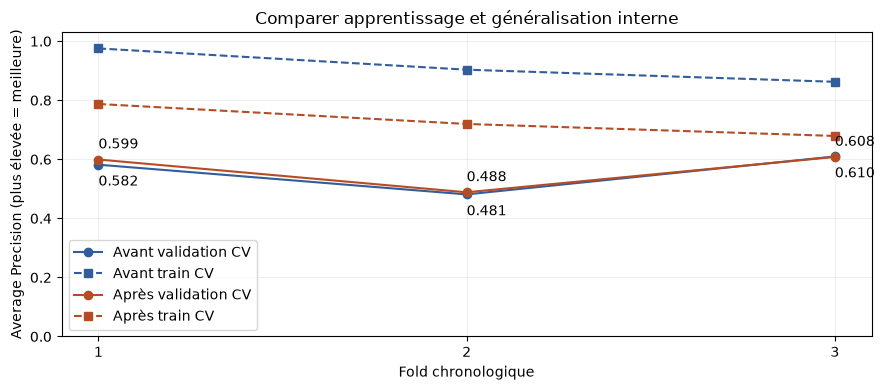

Variation de l’écart train-validation : -0.1928. Négative = écart réduit ; positive = écart accru. Aucun seuil universel ne prouve l’absence de surapprentissage.


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for title, r, color in [('Avant', baseline, '#315D9B'), ('Après', best, '#B54C25')]:
    ax.plot([1,2,3], r['scores'], 'o-', color=color, label=f'{title} validation CV')
    ax.plot([1,2,3], r['train_scores'], 's--', color=color, label=f'{title} train CV')
    for i, value in enumerate(r['scores'], 1):
        ax.annotate(f'{value:.3f}', (i, value), xytext=(0, 8 if title=='Après' else -15), textcoords='offset points')
    print(f'{title} : moyenne CV {r["cv_ap"]:.4f}, dispersion {r["cv_std"]:.4f}, '
          f'train {r["train_ap"]:.4f}, écart {r["gap_ap"]:+.4f}.')
ax.set(xlabel='Fold chronologique', ylabel='Average Precision (plus élevée = meilleure)',
       ylim=(0, 1.03), xticks=[1,2,3], title='Comparer apprentissage et généralisation interne')
ax.legend(loc='best'); ax.grid(alpha=.2); plt.tight_layout(); plt.show()
print(f'Variation de l’écart train-validation : {best["gap_ap"]-baseline["gap_ap"]:+.4f}. '
      'Négative = écart réduit ; positive = écart accru. Aucun seuil universel ne prouve l’absence de surapprentissage.')

## 7. Fixer le seuil sur la validation dédiée

Un **seuil** transforme le score de la forêt en alerte : score ≥ seuil → classe 1. Avec des poids de classe, ce score n'est pas nécessairement une probabilité calibrée : 0,40 ne signifie pas une probabilité réelle de panne de 40 %.

Le **F2** combine précision P et rappel R : `F2 = 5 × P × R / (4 × P + R)` ; il donne plus de poids au rappel afin de limiter les pannes manquées. Ce choix traduit une préférence pédagogique ; aucun coût métier chiffré n'est disponible pour justifier économiquement le facteur 2. Le seuil de chaque modèle maximise F2 **sur la validation dédiée seulement**. Un F2 mesuré sur cette même validation est optimiste, car le seuil y a été choisi.

La matrice de confusion compte : **VP** (vrais positifs détectés), **FN** (positifs manqués), **FP** (alertes sur des négatifs), **VN** (négatifs sans alerte). Le notebook explique chaque nombre et son dénominateur. Les scores AP et ROC-AUC n'utilisent pas le seuil. Les différences sur F2 combinent l'effet du modèle et celui de son seuil.

In [7]:
def choose_threshold(target, scores):
    p, r, thresholds = precision_recall_curve(target, scores)
    f2 = 5*p[:-1]*r[:-1] / (4*p[:-1] + r[:-1] + np.finfo(float).eps)
    # En cas d'égalité, premier maximum : seuil le plus bas, priorité au rappel.
    return float(thresholds[np.argmax(f2)])

def measure(target, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(target, pred, labels=[0,1]).ravel()
    return {'AP': float(average_precision_score(target, scores)),
            'ROC_AUC': float(roc_auc_score(target, scores)),
            'precision': float(precision_score(target, pred, zero_division=0)),
            'recall': float(recall_score(target, pred, zero_division=0)),
            'F2': float(fbeta_score(target, pred, beta=2, zero_division=0)),
            'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn), 'threshold': threshold}

def explain(title, m, target):
    n, positives = len(target), int(target.sum())
    print(f'\n{title} — {n} machine-heures, dont {positives} positives ({target.mean():.2%}).')
    print(f'AP {m["AP"]:.4f} : qualité du classement précision-rappel, '
          f'{m["AP"]-target.mean():+.4f} au-dessus du repère de prévalence {target.mean():.4f}. '
          f'ROC-AUC {m["ROC_AUC"]:.4f} : classement positif/négatif (repère aléatoire 0.5).')
    print(f'Seuil {m["threshold"]:.4f} : une alerte est émise au-dessus ou à cette valeur, '
          'fixée sur validation et non optimisée sur le test.')
    print(f'VP={m["TP"]} : positifs détectés ; FN={m["FN"]} : positifs manqués ; '
          f'FP={m["FP"]} : alertes erronées ; VN={m["TN"]} : négatifs correctement laissés sans alerte.')
    print(f'Précision {m["precision"]:.2%} = {m["TP"]}/{m["TP"]+m["FP"]} alertes correctes ; '
          f'rappel {m["recall"]:.2%} = {m["TP"]}/{positives} positifs détectés ; '
          f'F2 {m["F2"]:.4f} combine ces deux taux en privilégiant le rappel.')
    assert m['TP']+m['FP']+m['FN']+m['TN'] == n

models, thresholds, validation_results = {}, {}, {}
for label, result in [('Avant', baseline), ('Après', best)]:
    # Recharger réellement le modèle sauvegardé vérifie aussi sa lisibilité dans MLflow.
    models[label] = mlflow.sklearn.load_model(result['model_uri'])
    val_scores = models[label].predict_proba(X['validation'])[:,1]
    thresholds[label] = choose_threshold(y['validation'], val_scores)
    validation_results[label] = measure(y['validation'], val_scores, thresholds[label])
    explain(label + ' / validation', validation_results[label], y['validation'])
print('MODELES_ET_SEUILS_FIGES : le test peut maintenant être évalué.')


Avant / validation — 19785 machine-heures, dont 3404 positives (17.20%).
AP 0.5941 : qualité du classement précision-rappel, +0.4221 au-dessus du repère de prévalence 0.1720. ROC-AUC 0.7597 : classement positif/négatif (repère aléatoire 0.5).
Seuil 0.3299 : une alerte est émise au-dessus ou à cette valeur, fixée sur validation et non optimisée sur le test.
VP=2167 : positifs détectés ; FN=1237 : positifs manqués ; FP=3878 : alertes erronées ; VN=12503 : négatifs correctement laissés sans alerte.
Précision 35.85% = 2167/6045 alertes correctes ; rappel 63.66% = 2167/3404 positifs détectés ; F2 0.5511 combine ces deux taux en privilégiant le rappel.

Après / validation — 19785 machine-heures, dont 3404 positives (17.20%).
AP 0.5736 : qualité du classement précision-rappel, +0.4015 au-dessus du repère de prévalence 0.1720. ROC-AUC 0.7398 : classement positif/négatif (repère aléatoire 0.5).
Seuil 0.3494 : une alerte est émise au-dessus ou à cette valeur, fixée sur validation et non optimis

## 8. Comparaison finale sur le test historique

On calcule les performances **une fois après gel** et on ne revient pas modifier les réglages selon ces résultats. « Après » signifie gagnant de la recherche ; cela ne présuppose aucun progrès. Dans le tableau, `delta` = après moins avant : positif est souhaitable pour AP, précision, rappel, F2 et ROC-AUC ; négatif est souhaitable pour FP et FN. Le seuil n'a pas de sens de progression intrinsèque.

Les observations horaires se recouvrent : plusieurs positifs peuvent annoncer le même incident. Les nombres FP/FN ne sont donc pas directement des nombres d'incidents ou d'interventions. Pour une validation industrielle, il faudra regrouper les alertes par incident et mesurer les délais d'anticipation.

In [8]:
test_results = {}
for label, model in models.items():
    test_scores = model.predict_proba(X['test'])[:,1]
    test_results[label] = measure(y['test'], test_scores, thresholds[label])
    explain(label + ' / test', test_results[label], y['test'])
comparison = pd.DataFrame(test_results).T
comparison.loc['delta'] = comparison.loc['Après'] - comparison.loc['Avant']
display(comparison.round(4))
for metric in ['AP', 'ROC_AUC', 'precision', 'recall', 'F2']:
    delta = comparison.loc['delta', metric]
    print(f'{metric} : variation {delta:+.4f} point, soit {100*delta:+.2f} points sur une échelle 0–100 ; '
          'ce ne sont pas des pourcents de gain relatif.')
print(f'FP : {comparison.loc["delta","FP"]:+.0f} alertes erronées ; '
      f'FN : {comparison.loc["delta","FN"]:+.0f} machine-heures positives manquées.')
ap_delta = test_results['Après']['AP'] - test_results['Avant']['AP']
print('CONCLUSION TEST :', 'AP améliorée.' if ap_delta > 0 else 'Pas de gain AP sur ce test historique.')
print('L’absence de surapprentissage n’est pas démontrée : lire les écarts train/CV, '
      'la variabilité temporelle et confirmer sur une période future jamais consultée.')


Avant / test — 20145 machine-heures, dont 3478 positives (17.26%).
AP 0.6151 : qualité du classement précision-rappel, +0.4425 au-dessus du repère de prévalence 0.1726. ROC-AUC 0.7737 : classement positif/négatif (repère aléatoire 0.5).
Seuil 0.3299 : une alerte est émise au-dessus ou à cette valeur, fixée sur validation et non optimisée sur le test.
VP=2354 : positifs détectés ; FN=1124 : positifs manqués ; FP=4423 : alertes erronées ; VN=12244 : négatifs correctement laissés sans alerte.
Précision 34.74% = 2354/6777 alertes correctes ; rappel 67.68% = 2354/3478 positifs détectés ; F2 0.5689 combine ces deux taux en privilégiant le rappel.

Après / test — 20145 machine-heures, dont 3478 positives (17.26%).
AP 0.5971 : qualité du classement précision-rappel, +0.4245 au-dessus du repère de prévalence 0.1726. ROC-AUC 0.7762 : classement positif/négatif (repère aléatoire 0.5).
Seuil 0.3494 : une alerte est émise au-dessus ou à cette valeur, fixée sur validation et non optimisée sur le te

,AP,ROC_AUC,precision,recall,F2,TP,FP,FN,TN,threshold
Avant,0.6151,0.7737,0.3474,0.6768,0.5689,2354.0,4423.0,1124.0,12244.0,0.3299
Après,0.5971,0.7762,0.3436,0.6771,0.5670,2355.0,4499.0,1123.0,12168.0,0.3494
delta,-0.0180,0.0025,-0.0038,0.0003,-0.0019,1.0,76.0,-1.0,-76.0,0.0194


AP : variation -0.0180 point, soit -1.80 points sur une échelle 0–100 ; ce ne sont pas des pourcents de gain relatif.
ROC_AUC : variation +0.0025 point, soit +0.25 points sur une échelle 0–100 ; ce ne sont pas des pourcents de gain relatif.
precision : variation -0.0038 point, soit -0.38 points sur une échelle 0–100 ; ce ne sont pas des pourcents de gain relatif.
recall : variation +0.0003 point, soit +0.03 points sur une échelle 0–100 ; ce ne sont pas des pourcents de gain relatif.
F2 : variation -0.0019 point, soit -0.19 points sur une échelle 0–100 ; ce ne sont pas des pourcents de gain relatif.
FP : +76 alertes erronées ; FN : -1 machine-heures positives manquées.
CONCLUSION TEST : Pas de gain AP sur ce test historique.
L’absence de surapprentissage n’est pas démontrée : lire les écarts train/CV, la variabilité temporelle et confirmer sur une période future jamais consultée.


### Matrices de confusion : avant et après, au seuil figé

Chaque **matrice de confusion** croise la classe réelle (lignes) et la décision du modèle (colonnes). En haut à gauche : **VN**, absence de panne correctement reconnue ; en haut à droite : **FP**, fausse alerte ; en bas à gauche : **FN**, panne à venir manquée ; en bas à droite : **VP**, panne à venir détectée.

Chaque case affiche un **effectif de machine-heures** et son **pourcentage dans la classe réelle**, donc dans sa ligne. Les deux cases de chaque ligne totalisent 100 %. En bas à droite, le pourcentage est le rappel ; en bas à gauche, c'est la proportion des positifs manqués. En haut à droite, il s'agit du taux de fausses alertes parmi les négatifs, et non de la part des fausses alertes parmi toutes les alertes. La couleur utilise ces pourcentages, avec la même échelle dans les deux graphiques pour comparer malgré le déséquilibre des classes.

Les deux modèles utilisent leurs seuils respectifs choisis sur la validation : la comparaison porte donc sur le système modèle + seuil. Les nombres ci-dessous proviennent exactement des prédictions test déjà évaluées ; aucun nouvel entraînement ni réglage n'est effectué.

Avant : ligne sans panne = 16667 observations ; ligne panne = 3478 observations. Taux de fausses alertes parmi les négatifs = 26.54% ; taux de positifs manqués = 32.32%.
Après : ligne sans panne = 16667 observations ; ligne panne = 3478 observations. Taux de fausses alertes parmi les négatifs = 26.99% ; taux de positifs manqués = 32.29%.


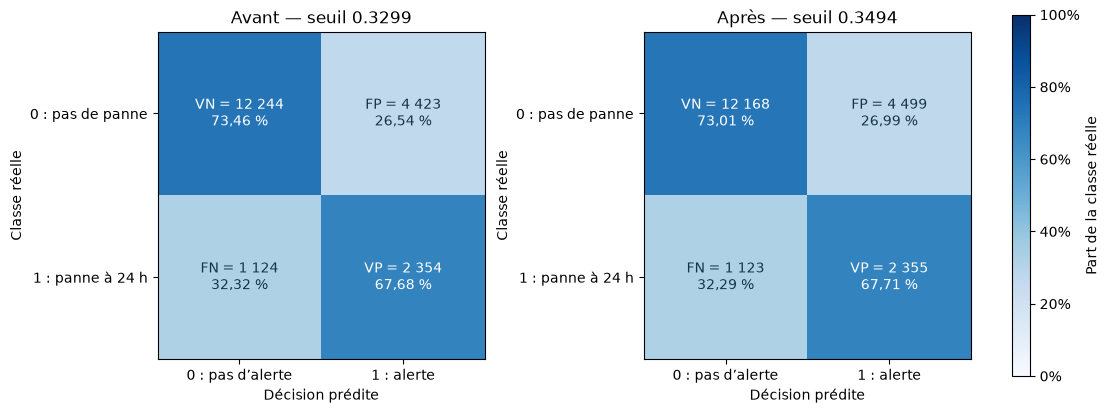

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout='constrained')
for ax, label in zip(axes, ['Avant', 'Après']):
    m = test_results[label]
    counts = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    row_rates = counts / counts.sum(axis=1, keepdims=True)
    im = ax.imshow(row_rates, cmap='Blues', vmin=0, vmax=1)
    names = [['VN', 'FP'], ['FN', 'VP']]
    for row in range(2):
        for col in range(2):
            annotation = f'{names[row][col]} = {counts[row,col]:,}'.replace(',', ' ')
            annotation += '\n' + f'{100 * row_rates[row,col]:.2f} %'.replace('.', ',')
            ax.text(col, row, annotation,
                    ha='center', va='center', fontsize=10,
                    color='white' if row_rates[row,col] > .55 else '#17354A')
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['0 : pas d’alerte', '1 : alerte'],
           yticklabels=['0 : pas de panne', '1 : panne à 24 h'],
           xlabel='Décision prédite', ylabel='Classe réelle',
           title=f'{label} — seuil {m["threshold"]:.4f}')
    print(f'{label} : ligne sans panne = {m["TN"]+m["FP"]} observations ; '
          f'ligne panne = {m["FN"]+m["TP"]} observations. '
          f'Taux de fausses alertes parmi les négatifs = {row_rates[0,1]:.2%} ; '
          f'taux de positifs manqués = {row_rates[1,0]:.2%}.')
fig.colorbar(im, ax=axes, shrink=.8, label='Part de la classe réelle', format=PercentFormatter(1))
from pathlib import Path
figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
figure_dir = figure_root / 'outputs/optimisation'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'matrices-confusion.png', dpi=160)
import mlflow
mlflow.tracking.MlflowClient().log_artifact(PARENT_ID, str(figure_dir / 'matrices-confusion.png'))
plt.show()


## 9. Sauvegarder le bilan et comparer dans MLflow

La cellule conserve les tableaux et la synthèse dans les artefacts de la campagne ; un JSON (fichier de données structuré) facilite la vérification du livrable. Chaque réexécution crée une nouvelle campagne et conserve les anciennes. Aucun essai échoué n'est effacé.

Dans le navigateur ouvert sur **http://127.0.0.1:5000** :
1. Sélectionner **Model training** (et non la vue GenAI), puis ouvrir **Experiments** et `indusense-random-search-pedagogique`.
2. Ouvrir la campagne dont l'identifiant est affiché ci-dessous ; développer ses runs enfants.
3. Afficher les colonnes `params.max_depth`, `params.min_samples_leaf`, `params.n_estimators`, `params.max_features`, `metrics.cv_ap`, `metrics.cv_std`, `metrics.gap_ap`, `metrics.cv_seconds`.
4. Sélectionner plusieurs essais puis **Compare** pour comparer paramètres et métriques. Trier `cv_ap` décroissant : plus grand = meilleur score moyen interne. Filtrer le tag `role` pour distinguer `recherche`, `reference` et `sensibilite` ; une sonde de sensibilité n'est pas un nouvel essai de sélection.
5. Dans un run, ouvrir **Artifacts** ou **Models** selon la version : le modèle `modele` est le pipeline réentraîné. Dans la campagne, ouvrir `protocole.json`, `comparaison-test.csv` et `synthese.md`.

**Dépannage :** interface vide → vérifier le nom d'expérience et la base `.mlflow/mlflow.db` ; `ModuleNotFoundError` → mauvais noyau, sélectionner `.venv` ; assertion temporelle → inspecter dates et CSV, ne pas supprimer le contrôle ; exécution longue → attendre l'état de la cellule, ne pas la relancer en double ; échec → consulter la trace et le run `FAILED`. Fermer un onglet n'arrête pas le serveur : utiliser `Ctrl+C` dans son terminal. Le suivi local n'est pas un serveur partagé ni une sauvegarde distante.

In [9]:
elapsed = perf_counter() - campaign_started
unique_configs = len(cache)
fit_count = unique_configs * (N_FOLDS + 1)
summary = f'''# Optimisation Indusense — synthèse

**Besoin.** Classer les machine-heures selon le risque de panne à 24 h. Random Forest retenue dans les travaux antérieurs ; référence manuelle réentraînée avec le même protocole.

**Méthode et justification.** Random Search : {N_TRIALS} configurations parmi 64, graine 42, trois folds chronologiques internes au train, gap de 24 h. Budget borné et simplicité adaptés à un espace déjà plausible ; Grid Search serait exhaustive mais plus coûteuse, Optuna adapterait les essais à leur historique mais demanderait une logique supplémentaire. AP (Average Precision) optimisée pour la classe positive minoritaire ; imputation apprise dans chaque fold. Validation dédiée pour le seuil F2, test exclu de tout réglage.

**Espace.** Nombre d'arbres 150/300 ; profondeur 6/8/12/16 ; minimum par feuille 2/5/10/20 ; variables par séparation sqrt/0.25. Pondération balanced_subsample fixe. Gagnant : {best['params']}.

**Résultats avant → après.** AP CV {baseline['cv_ap']:.4f} → {best['cv_ap']:.4f} ; dispersion CV {baseline['cv_std']:.4f} → {best['cv_std']:.4f}. AP test {test_results['Avant']['AP']:.4f} → {test_results['Après']['AP']:.4f} (variation {ap_delta:+.4f}). F2 test {test_results['Avant']['F2']:.4f} → {test_results['Après']['F2']:.4f} ; rappel {test_results['Avant']['recall']:.2%} → {test_results['Après']['recall']:.2%} ; précision {test_results['Avant']['precision']:.2%} → {test_results['Après']['precision']:.2%}. FP {test_results['Avant']['FP']} → {test_results['Après']['FP']} ; FN {test_results['Avant']['FN']} → {test_results['Après']['FN']}. Seuils choisis sur validation {thresholds['Avant']:.4f} → {thresholds['Après']:.4f}.

**Influence et généralisation.** Réglage localement le plus sensible : {influence.iloc[0]['hyperparametre']} (amplitude AP {influence.iloc[0]['amplitude_ap']:.4f}), autres réglages constants. Écart train-CV {baseline['gap_ap']:.4f} → {best['gap_ap']:.4f}. La dispersion des trois folds n'est pas un intervalle de confiance ; interactions et dépendances temporelles subsistent. Le test a déjà été consulté auparavant : résultats pédagogiques, absence de surapprentissage non prouvée.

**Coût et décision.** {unique_configs} configurations inédites, {fit_count} fits incluant les refits archivés, {elapsed/60:.1f} minutes jusqu'au bilan (journalisation comprise). {'Gain AP observé sur ce test.' if ap_delta>0 else 'Aucun gain AP sur ce test.'} Ne pas décider du déploiement à partir de ce test recyclé : confirmer sur une période inédite et des métriques par incident. MLflow conserve paramètres, scores des folds, modèles, versions et empreinte des données. Énergie/CO₂ non mesurés. Cours : 09_Optimisation.pdf, p. 4–10.
'''
OUTPUT = ROOT / 'outputs/optimisation'
OUTPUT.mkdir(parents=True, exist_ok=True)
payload = dict(parent_run_id=PARENT_ID, experiment_id=experiment.experiment_id,
    versions=versions, dataset_sha256=DATA_SHA256, baseline=baseline, best=best,
    test=test_results, validation=validation_results,
    influence=influence.to_dict('records'), unique_configs=unique_configs,
    fit_count=fit_count, elapsed_seconds=elapsed, trials=trials)
(OUTPUT / 'resultats.json').write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding='utf-8')
summary_path = ROOT / 'docs/02-sprint-2/03-suivi/03-synthese-optimisation-mlflow.md'
summary_path.write_text(summary, encoding='utf-8')
comparison.to_csv(OUTPUT / 'comparaison-test.csv', index_label='modele')
with mlflow.start_run(run_id=PARENT_ID):
    for label, metrics in test_results.items():
        mlflow.log_metrics({f'test_{"avant" if label=="Avant" else "apres"}_{k}': v for k,v in metrics.items()})
    mlflow.log_metrics({'total_fits': fit_count, 'elapsed_seconds': elapsed})
    mlflow.log_artifact(str(OUTPUT / 'comparaison-test.csv'))
    mlflow.log_artifact(str(OUTPUT / 'resultats.json'))
    mlflow.log_text(summary, 'synthese.md')
display(Markdown(summary))
print(f'Campagne MLflow : {PARENT_ID} (identifiant, pas un score).')
print(f'Coût : {unique_configs} configurations distinctes × 4 fits = {fit_count} fits ; '
      f'{elapsed/60:.1f} minutes écoulées, sans mesure énergétique.')
print('NOTEBOOK_OPTIMISATION_MLFLOW_VALIDE')

# Optimisation Indusense — synthèse

**Besoin.** Classer les machine-heures selon le risque de panne à 24 h. Random Forest retenue dans les travaux antérieurs ; référence manuelle réentraînée avec le même protocole.

**Méthode et justification.** Random Search : 16 configurations parmi 64, graine 42, trois folds chronologiques internes au train, gap de 24 h. Budget borné et simplicité adaptés à un espace déjà plausible ; Grid Search serait exhaustive mais plus coûteuse, Optuna adapterait les essais à leur historique mais demanderait une logique supplémentaire. AP (Average Precision) optimisée pour la classe positive minoritaire ; imputation apprise dans chaque fold. Validation dédiée pour le seuil F2, test exclu de tout réglage.

**Espace.** Nombre d'arbres 150/300 ; profondeur 6/8/12/16 ; minimum par feuille 2/5/10/20 ; variables par séparation sqrt/0.25. Pondération balanced_subsample fixe. Gagnant : {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 0.25, 'max_depth': 6}.

**Résultats avant → après.** AP CV 0.5575 → 0.5652 ; dispersion CV 0.0552 → 0.0545. AP test 0.6151 → 0.5971 (variation -0.0180). F2 test 0.5689 → 0.5670 ; rappel 67.68% → 67.71% ; précision 34.74% → 34.36%. FP 4423 → 4499 ; FN 1124 → 1123. Seuils choisis sur validation 0.3299 → 0.3494.

**Influence et généralisation.** Réglage localement le plus sensible : max_depth (amplitude AP 0.0103), autres réglages constants. Écart train-CV 0.3563 → 0.1635. La dispersion des trois folds n'est pas un intervalle de confiance ; interactions et dépendances temporelles subsistent. Le test a déjà été consulté auparavant : résultats pédagogiques, absence de surapprentissage non prouvée.

**Coût et décision.** 23 configurations inédites, 92 fits incluant les refits archivés, 21.9 minutes jusqu'au bilan (journalisation comprise). Aucun gain AP sur ce test. Ne pas décider du déploiement à partir de ce test recyclé : confirmer sur une période inédite et des métriques par incident. MLflow conserve paramètres, scores des folds, modèles, versions et empreinte des données. Énergie/CO₂ non mesurés. Cours : 09_Optimisation.pdf, p. 4–10.


Campagne MLflow : 99cc410899444835a062c4156c611cc6 (identifiant, pas un score).
Coût : 23 configurations distinctes × 4 fits = 92 fits ; 21.9 minutes écoulées, sans mesure énergétique.
NOTEBOOK_OPTIMISATION_MLFLOW_VALIDE


## 10. Préparer la présentation orale et faire le bilan

**Formulation à personnaliser avec les chiffres calculés :** « J'ai choisi une recherche aléatoire de 16 configurations de Random Forest car elle maîtrise le coût tout en couvrant quatre hyperparamètres. Contrairement à une grille, elle ne teste pas toutes les combinaisons ; contrairement à Optuna, elle ne guide pas les nouveaux essais avec les anciens résultats. J'optimise l'Average Precision sur trois validations temporelles à l'intérieur du train, avec un gap de 24 heures et l'imputation dans le pipeline. Je fixe ensuite le seuil F2 sur la validation dédiée, puis je compare les deux modèles figés sur le test historique. Je distingue le gain de classement, les pannes manquées, les fausses alertes et le coût. MLflow conserve la trace de chaque configuration. Le test étant déjà connu, je demande une nouvelle période avant de conclure à la généralisation. »

**Erreurs à éviter :** appeler l'AP une accuracy ; confondre paramètres appris et hyperparamètres ; mélanger les heures entre folds ; considérer `gap=24` comme 24 heures sur des lignes de plusieurs machines ; imputer avant les folds ; sélectionner sur le test ; annoncer que le tuning garantit un gain ; confondre importance des hyperparamètres et importance des features ; interpréter une dispersion comme un intervalle de confiance ; compter des machine-heures positives comme des incidents distincts.

**Notions mises en pratique :** recherche sous budget, validation temporelle, prévention des fuites, métrique adaptée, choix d'un seuil, comparaison contrôlée, analyse de sensibilité et traçabilité des expériences. **Validé si le marqueur précédent apparaît :** calcul complet et export des résultats, lecture des modèles sauvegardés, cohérence des effectifs. **À valider encore :** stabilité sur d'autres périodes/graines, performance par incident, coût métier, calibration des scores et fonctionnement en production. Les correspondances détaillées C1 à C9 restent à confirmer avec le Kit candidat ; aucune compétence n'est réputée acquise par la seule exécution.

Documentation technique : [MLflow local SQLite](https://mlflow.org/docs/latest/ml/tracking/tutorials/local-database), [ParameterSampler](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterSampler.html), [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).